2025-01-20 12:51:04,106: E symspellpy.symspellpy] Dictionary file not found at frequency_dictionary_en_82_765.txt.
C:\Users\vaibh\miniconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
Neither CUDA nor MPS are available - defaulting to CPU. Note: This module is much faster with a GPU.
C:\Users\vaibh\miniconda3\Lib\site-packages\easyocr\detection.py:78: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release,

Detected: Advice;, Confidence: 0.7454
Detected: Syp CALPOL @so/5), Confidence: 0.6706
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 254ms/step
Low confidence detected. Using CRNN model prediction: s
Detected: Qeh * 3, Confidence: 0.7034
Detected: d, Confidence: 0.9582
Detected: SYp, Confidence: 0.4279
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
Low confidence detected. Using CRNN model prediction: s
Detected: Delcorv, Confidence: 0.4440
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
Low confidence detected. Using CRNN model prediction: d
Detected: 3 mL, Confidence: 0.8870
Detected: sd, Confidence: 0.9999
Detected: SYp, Confidence: 0.2568
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
Low confidence detected. Using CRNN model prediction: s
Detected: LEvoLIN, Confidence: 0.5628
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
Low confidence detected. Using CRNN model prediction: d
Detected: ML, Confidence: 0.6396
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
Low confidence detected. Using CRNN model prediction: d
Detected: sd, Confidence: 0.4546
1

C:\Users\vaibh\AppData\Local\Temp\ipykernel_1340\1202007276.py:124: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


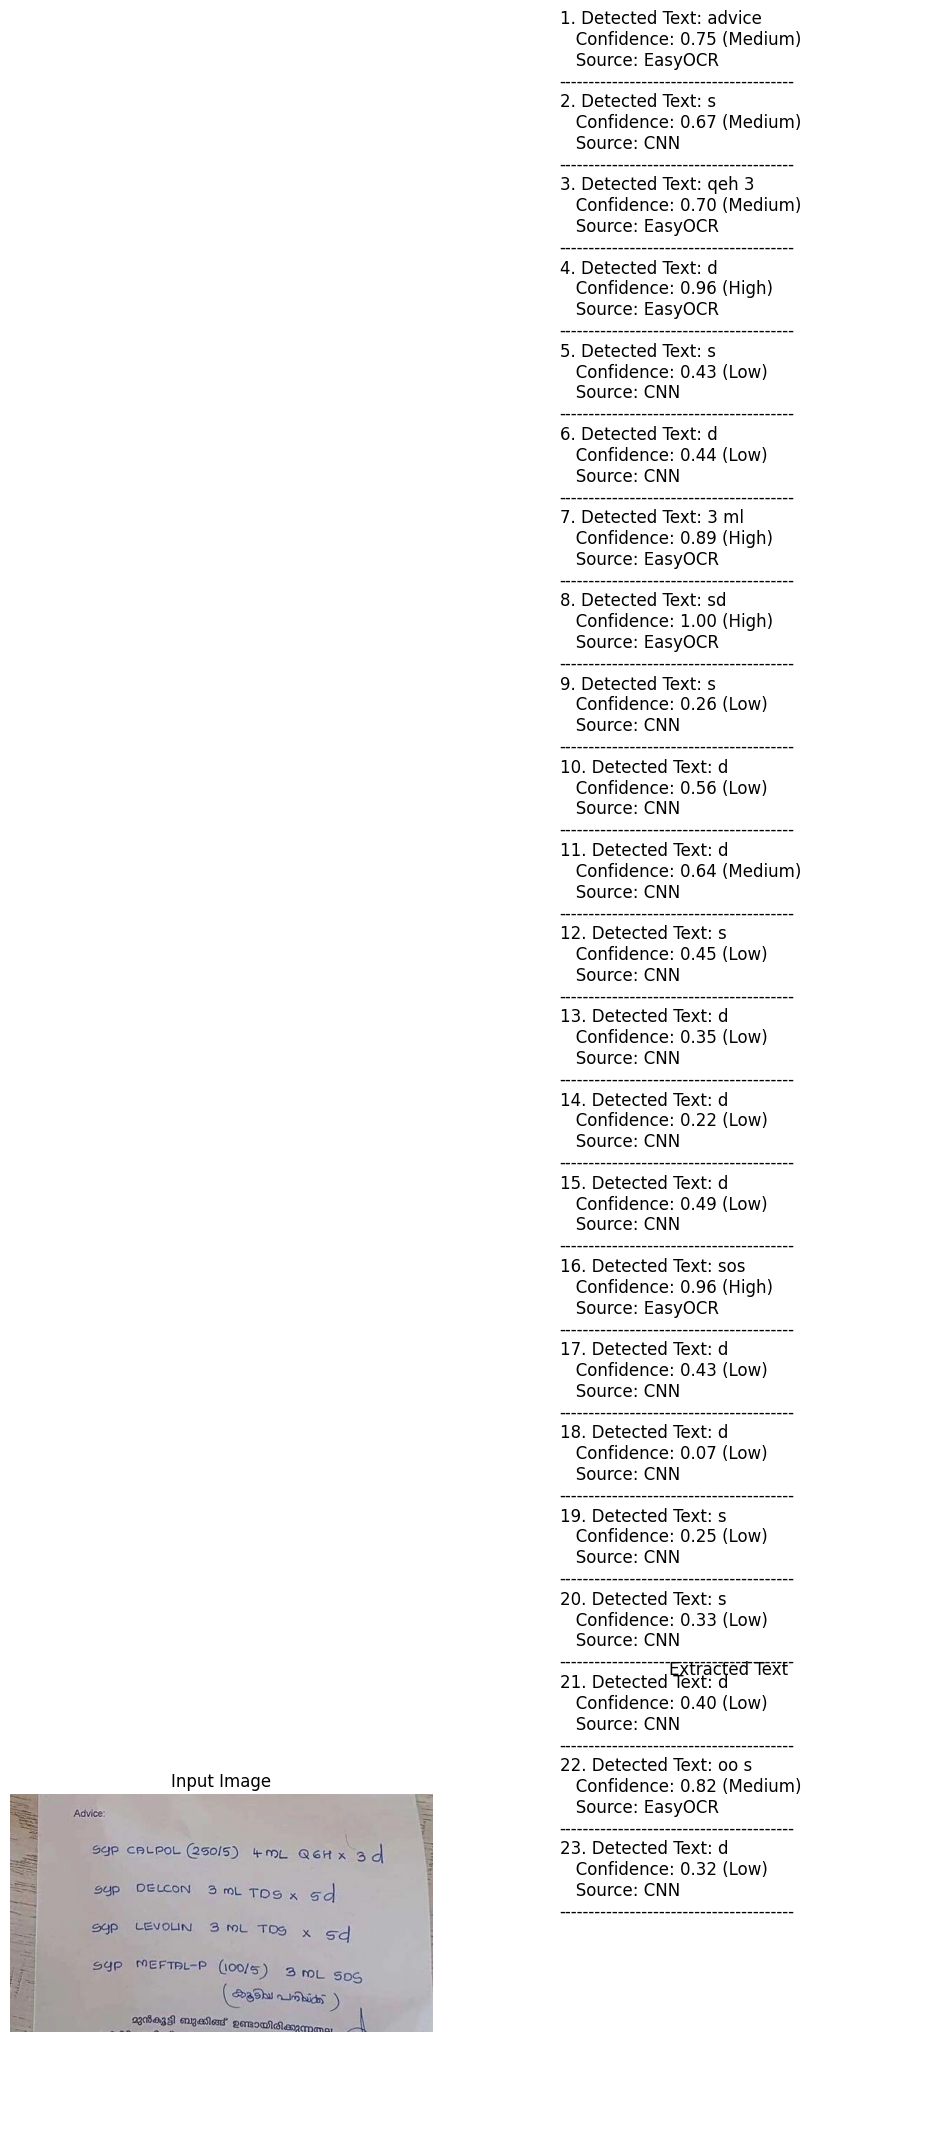

In [1]:
import easyocr
import numpy as np
import cv2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt
from symspellpy import SymSpell, Verbosity

# Initialize SymSpell for spelling correction
sym_spell = SymSpell(max_dictionary_edit_distance=2)
sym_spell.load_dictionary("frequency_dictionary_en_82_765.txt", 0, 1)

# Build a custom CNN model for 28x28 input
def build_crnn_model(input_shape=(28, 28, 1)):
    model = Sequential([
        Conv2D(32, (3, 3), activation='relu', input_shape=input_shape),
        MaxPooling2D((2, 2)),
        Conv2D(64, (3, 3), activation='relu'),
        MaxPooling2D((2, 2)),
        Flatten(),
        Dense(128, activation='relu'),
        Dropout(0.5),
        Dense(26, activation='softmax')  # 26 classes for A-Z
    ])
    model.compile(optimizer=Adam(learning_rate=1e-4), loss='categorical_crossentropy', metrics=['accuracy'])
    return model

# Initialize CRNN model
crnn_model = build_crnn_model()

# Class mapping
class_map = {i: chr(65 + i) for i in range(26)}

# Preprocessing function for CRNN
def preprocess_for_crnn(image):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    resized = cv2.resize(gray, (28, 28))  # Keep input size 28x28
    normalized = resized.astype('float32') / 255.0
    reshaped = np.expand_dims(normalized, axis=-1)
    return np.expand_dims(reshaped, axis=0)

# CRNN prediction
def extract_text_crnn(image):
    preprocessed_image = preprocess_for_crnn(image)
    prediction = crnn_model.predict(preprocessed_image)
    predicted_class = np.argmax(prediction, axis=-1)
    text = ''.join([class_map[char] for char in predicted_class])
    return text

# Dynamic thresholding for EasyOCR results
def dynamic_threshold(results, confidence_multiplier=0.5):
    avg_confidence = np.mean([conf for _, _, conf in results])
    return avg_confidence * confidence_multiplier

# Categorize confidence
def categorize_confidence(confidence):
    if confidence >= 0.85:
        return 'High'
    elif confidence >= 0.60:
        return 'Medium'
    else:
        return 'Low'

# Correct spelling using SymSpell
def correct_spelling(text):
    suggestions = sym_spell.lookup_compound(text, max_edit_distance=2)
    return suggestions[0].term if suggestions else text

# Hybrid OCR pipeline
def hybrid_ocr(image_path, confidence_threshold=0.7, min_crnn_confidence=0.5):
    reader = easyocr.Reader(['en'])
    image = cv2.imread(image_path)
    
    # Run EasyOCR
    results = reader.readtext(image, detail=1)
    prescription_text = []
    easyocr_count = 0
    crnn_count = 0

    for (bbox, text, confidence) in results:
        print(f"Detected: {text}, Confidence: {confidence:.4f}")

        # Use CRNN for low-confidence results
        if confidence < confidence_threshold:
            x_min, y_min = map(int, bbox[0])
            x_max, y_max = map(int, bbox[2])
            character_image = image[y_min:y_max, x_min:x_max]
            
            crnn_text = extract_text_crnn(character_image)
            crnn_text = correct_spelling(crnn_text)  # Apply spelling correction
            print(f"Low confidence detected. Using CRNN model prediction: {crnn_text}")
            prescription_text.append((crnn_text, confidence, 'CNN', categorize_confidence(confidence)))
            crnn_count += 1
        else:
            text = correct_spelling(text)  # Apply spelling correction
            prescription_text.append((text, confidence, 'EasyOCR', categorize_confidence(confidence)))
            easyocr_count += 1

    # Generate final extracted text
    final_text = "\n".join([f"{i+1}. Detected Text: {text}\n   Confidence: {confidence:.2f} ({category})\n   Source: {source}\n{'-'*40}"
                            for i, (text, confidence, source, category) in enumerate(prescription_text)])

    # Summary
    summary = f"\nSummary:\nTotal Results: {easyocr_count + crnn_count}\n - EasyOCR: {easyocr_count}\n - CRNN: {crnn_count}"

    print(f"\nFinal Extracted Text:\n{final_text}{summary}")
    return image, final_text.strip()

# Test the hybrid OCR pipeline
image_path = 'C:/Users/vaibh/Downloads/prescription5.jpg'
image, final_text = hybrid_ocr(image_path, confidence_threshold=0.7, min_crnn_confidence=0.5)

# Display results
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(cv2.imread(image_path), cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.title('Input Image')
plt.subplot(1, 2, 2)
plt.text(0.1, 0.5, final_text, fontsize=12, wrap=True)
plt.axis('off')
plt.title('Extracted Text')
plt.tight_layout()
plt.show()

2025-01-20 12:55:58,407: E symspellpy.symspellpy] Dictionary file not found at frequency_dictionary_en_82_765.txt.
Neither CUDA nor MPS are available - defaulting to CPU. Note: This module is much faster with a GPU.


Detected: Advice;, Confidence: 0.7454
Detected: Syp CALPOL @so/5), Confidence: 0.6706
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
Low confidence detected. Using CRNN model prediction: x
Detected: Qeh * 3, Confidence: 0.7034
Detected: d, Confidence: 0.9582
Detected: SYp, Confidence: 0.4279
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
Low confidence detected. Using CRNN model prediction: y
Detected: Delcorv, Confidence: 0.4440
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
Low confidence detected. Using CRNN model prediction: y
Detected: 3 mL, Confidence: 0.8870
Detected: sd, Confidence: 0.9999
Detected: SYp, Confidence: 0.2568
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
Low confidence detected. Using CRNN model prediction: y
Detected: LEvoLIN, Confidence: 0.5628
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
Low confidence detected. Using CRNN model prediction: x
Detected: ML, Confidence: 0.6396
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
Low confidence detected. Using CRNN model prediction: y
Detected: sd, Confidence: 0.4546
1/

C:\Users\vaibh\AppData\Local\Temp\ipykernel_1340\605786050.py:141: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


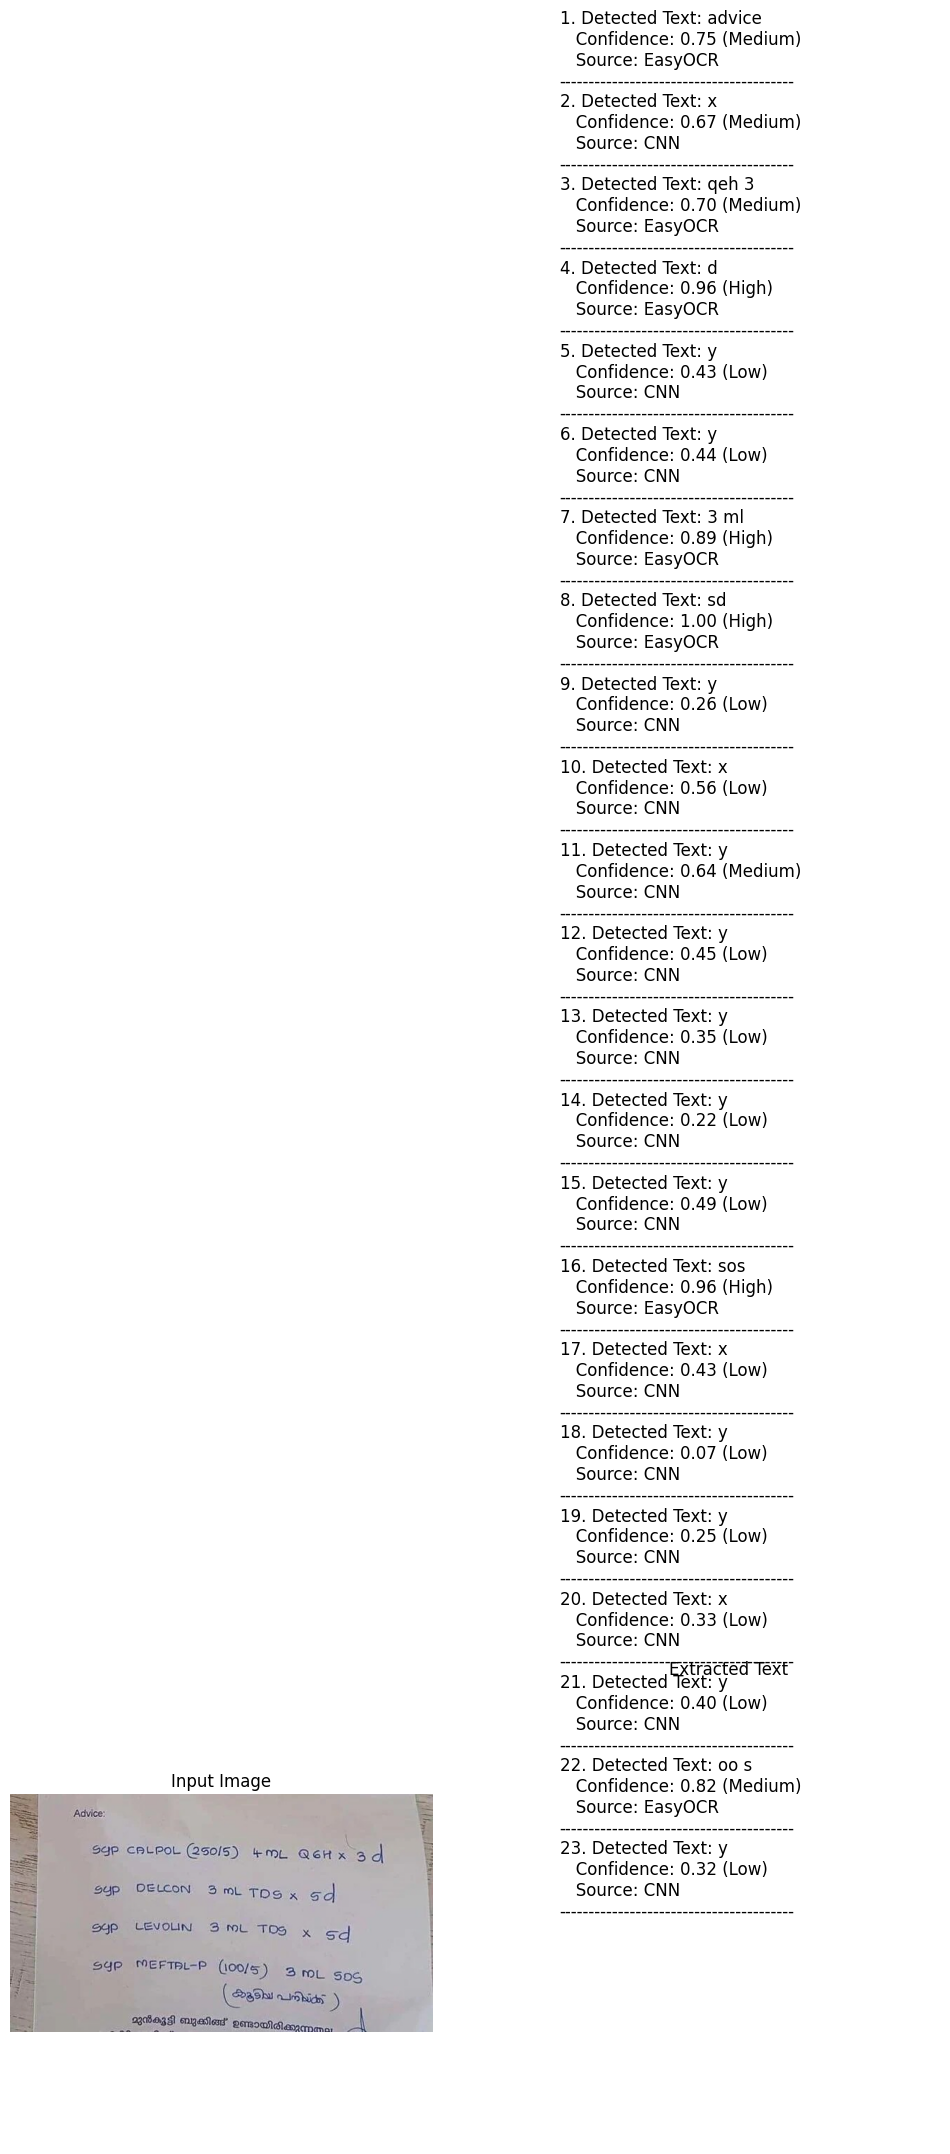

In [2]:
import easyocr
import numpy as np
import cv2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt
from symspellpy import SymSpell, Verbosity

# Initialize SymSpell for spelling correction
sym_spell = SymSpell(max_dictionary_edit_distance=2)
sym_spell.load_dictionary("frequency_dictionary_en_82_765.txt", 0, 1)

# Build a custom CNN model for 28x28 input
def build_crnn_model(input_shape=(28, 28, 1)):
    model = Sequential([
        Conv2D(32, (3, 3), activation='relu', input_shape=input_shape),
        MaxPooling2D((2, 2)),
        Conv2D(64, (3, 3), activation='relu'),
        MaxPooling2D((2, 2)),
        Flatten(),
        Dense(128, activation='relu'),
        Dropout(0.5),
        Dense(26, activation='softmax')  # 26 classes for A-Z
    ])
    model.compile(optimizer=Adam(learning_rate=1e-4), loss='categorical_crossentropy', metrics=['accuracy'])
    return model

# Initialize CRNN model
crnn_model = build_crnn_model()

# Class mapping
class_map = {i: chr(65 + i) for i in range(26)}

# Enhanced Preprocessing for CRNN
def enhanced_preprocess(image):
    # Convert to grayscale
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    
    # Apply Gaussian blur to reduce noise
    blurred = cv2.GaussianBlur(gray, (3, 3), 0)
    

    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    contrast_enhanced = clahe.apply(blurred)
    
   
    thresholded = cv2.adaptiveThreshold(
        contrast_enhanced, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 11, 2
    )
    
  
    resized = cv2.resize(thresholded, (28, 28), interpolation=cv2.INTER_AREA)
    
    
    normalized = resized.astype('float32') / 255.0
    reshaped = np.expand_dims(normalized, axis=-1)
    return np.expand_dims(reshaped, axis=0)

# CRNN prediction
def extract_text_crnn(image):
    preprocessed_image = enhanced_preprocess(image)
    prediction = crnn_model.predict(preprocessed_image)
    predicted_class = np.argmax(prediction, axis=-1)
    text = ''.join([class_map[char] for char in predicted_class])
    return text

# Dynamic thresholding for EasyOCR results
def dynamic_threshold(results, confidence_multiplier=0.5):
    avg_confidence = np.mean([conf for _, _, conf in results])
    return avg_confidence * confidence_multiplier

# Categorize confidence
def categorize_confidence(confidence):
    if confidence >= 0.85:
        return 'High'
    elif confidence >= 0.60:
        return 'Medium'
    else:
        return 'Low'

# Correct spelling using SymSpell
def correct_spelling(text):
    suggestions = sym_spell.lookup_compound(text, max_edit_distance=2)
    return suggestions[0].term if suggestions else text

# Hybrid OCR pipeline
def hybrid_ocr(image_path, confidence_threshold=0.7, min_crnn_confidence=0.5):
    reader = easyocr.Reader(['en'])
    image = cv2.imread(image_path)
    
    # Run EasyOCR
    results = reader.readtext(image, detail=1)
    prescription_text = []
    easyocr_count = 0
    crnn_count = 0

    for (bbox, text, confidence) in results:
        print(f"Detected: {text}, Confidence: {confidence:.4f}")

        # Use CRNN for low-confidence results
        if confidence < confidence_threshold:
            x_min, y_min = map(int, bbox[0])
            x_max, y_max = map(int, bbox[2])
            character_image = image[y_min:y_max, x_min:x_max]
            
            crnn_text = extract_text_crnn(character_image)
            crnn_text = correct_spelling(crnn_text)  # Apply spelling correction
            print(f"Low confidence detected. Using CRNN model prediction: {crnn_text}")
            prescription_text.append((crnn_text, confidence, 'CNN', categorize_confidence(confidence)))
            crnn_count += 1
        else:
            text = correct_spelling(text)  # Apply spelling correction
            prescription_text.append((text, confidence, 'EasyOCR', categorize_confidence(confidence)))
            easyocr_count += 1

    # Generate final extracted text
    final_text = "\n".join([f"{i+1}. Detected Text: {text}\n   Confidence: {confidence:.2f} ({category})\n   Source: {source}\n{'-'*40}"
                            for i, (text, confidence, source, category) in enumerate(prescription_text)])

    # Summary
    summary = f"\nSummary:\nTotal Results: {easyocr_count + crnn_count}\n - EasyOCR: {easyocr_count}\n - CRNN: {crnn_count}"

    print(f"\nFinal Extracted Text:\n{final_text}{summary}")
    return image, final_text.strip()

# Test the hybrid OCR pipeline
image_path = 'C:/Users/vaibh/Downloads/prescription5.jpg'
image, final_text = hybrid_ocr(image_path, confidence_threshold=0.7, min_crnn_confidence=0.5)

# Display results
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(cv2.imread(image_path), cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.title('Input Image')
plt.subplot(1, 2, 2)
plt.text(0.1, 0.5, final_text, fontsize=12, wrap=True)
plt.axis('off')
plt.title('Extracted Text')
plt.tight_layout()
plt.show()


2025-02-07 18:34:47,825: E symspellpy.symspellpy] Dictionary file not found at frequency_dictionary_en_82_765.txt.
Neither CUDA nor MPS are available - defaulting to CPU. Note: This module is much faster with a GPU.



Final Extracted Text:
 advice (Confidence: 0.60)
syp calpol sois (Confidence: 0.42)
qgh 3 (Confidence: 0.57)
d (Confidence: 0.73)
syp (Confidence: 0.28)
delconv (Confidence: 0.19)
ml tds (Confidence: 0.60)
sd (Confidence: 0.99)
syp (Confidence: 0.30)
levolin (Confidence: 0.93)
ml (Confidence: 0.83)
sd (Confidence: 0.99)
syp (Confidence: 0.66)
meftpl p (Confidence: 0.16)
tl (Confidence: 0.78)
sos (Confidence: 0.81)
e3511 jiokids (Confidence: 0.09)
9308038 mpalast ganoalldla (Confidence: 0.14)
ml (Confidence: 0.13)
tos (Confidence: 0.59)
oo s (Confidence: 0.54)


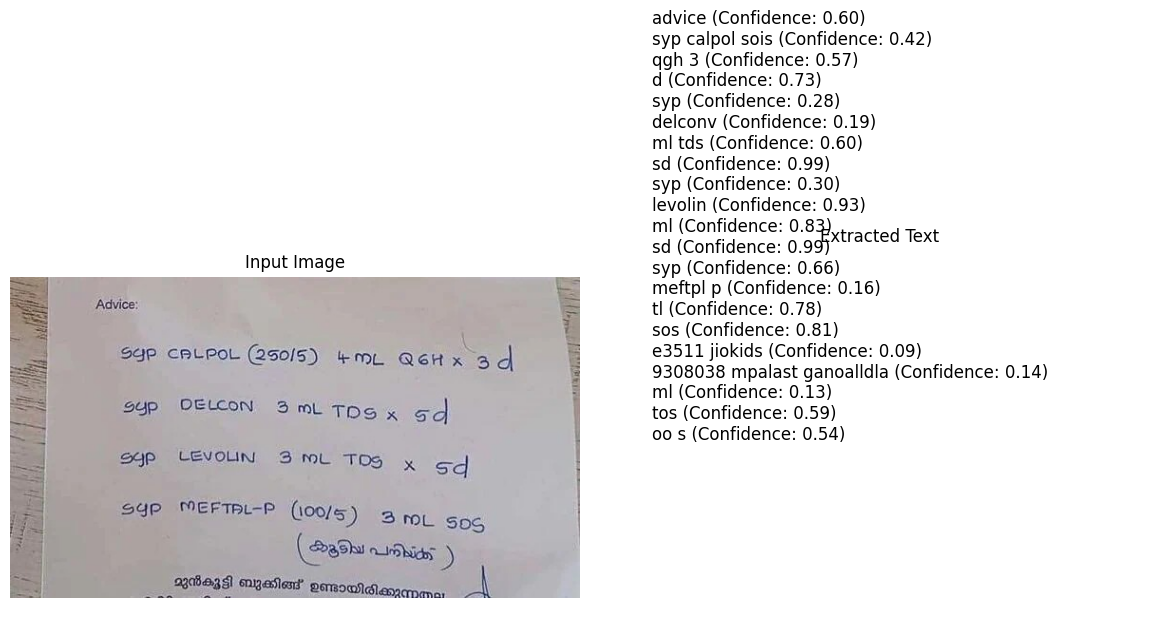

In [7]:
import easyocr
import numpy as np
import cv2
import matplotlib.pyplot as plt
from symspellpy import SymSpell, Verbosity

# Initialize SymSpell for spelling correction
sym_spell = SymSpell(max_dictionary_edit_distance=2)
sym_spell.load_dictionary("frequency_dictionary_en_82_765.txt", 0, 1)

# Preprocessing function
def preprocess_image(image):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    blurred = cv2.GaussianBlur(gray, (3, 3), 0)
    return blurred

# Correct spelling using SymSpell
def correct_spelling(text):
    suggestions = sym_spell.lookup_compound(text, max_edit_distance=2)
    return suggestions[0].term if suggestions else text

# Hybrid OCR pipeline (EasyOCR + Spelling Correction)
def hybrid_ocr(image_path, confidence_threshold=0.7):
    reader = easyocr.Reader(['en'])
    image = cv2.imread(image_path)
    image = preprocess_image(image)

    # Run EasyOCR
    results = reader.readtext(image, detail=1)
    extracted_text = []

    for (bbox, text, confidence) in results:
        corrected_text = correct_spelling(text)
        extracted_text.append(f"{corrected_text} (Confidence: {confidence:.2f})")

    # Generate final extracted text
    final_text = "\n".join(extracted_text)

    print("\nFinal Extracted Text:\n", final_text)
    return image, final_text.strip()

# Test the OCR pipeline
image_path = 'C:/Users/vaibh/Downloads/prescription5.jpg'
image, final_text = hybrid_ocr(image_path, confidence_threshold=0.7)

# Display results
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(cv2.imread(image_path), cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.title('Input Image')

plt.subplot(1, 2, 2)
plt.text(0.1, 0.5, final_text, fontsize=12, wrap=True)
plt.axis('off')
plt.title('Extracted Text')

plt.tight_layout()
plt.show()


2025-02-07 18:41:45,714: E symspellpy.symspellpy] Dictionary file not found at frequency_dictionary_en_82_765.txt.
Neither CUDA nor MPS are available - defaulting to CPU. Note: This module is much faster with a GPU.



Final Extracted Text:
 friio (Confidence: 0.16)
12 1 2629 (Confidence: 0.20)
r (Confidence: 1.00)
7 (Confidence: 0.76)
rabici p (Confidence: 0.70)
on e (Confidence: 0.48)
0 (Confidence: 0.29)
meals (Confidence: 0.99)
aks (Confidence: 0.31)
t (Confidence: 0.75)
lymo ral (Confidence: 0.31)
ap (Confidence: 0.49)
13 (Confidence: 0.16)
aften (Confidence: 0.32)
meals (Confidence: 0.99)
dars (Confidence: 0.38)
xeawops (Confidence: 0.13)
53 (Confidence: 0.15)
in (Confidence: 0.73)
bat6 (Confidence: 0.27)
hu (Confidence: 0.28)
before (Confidence: 0.65)
sells (Confidence: 0.22)
quin (Confidence: 0.37)
eye (Confidence: 0.90)


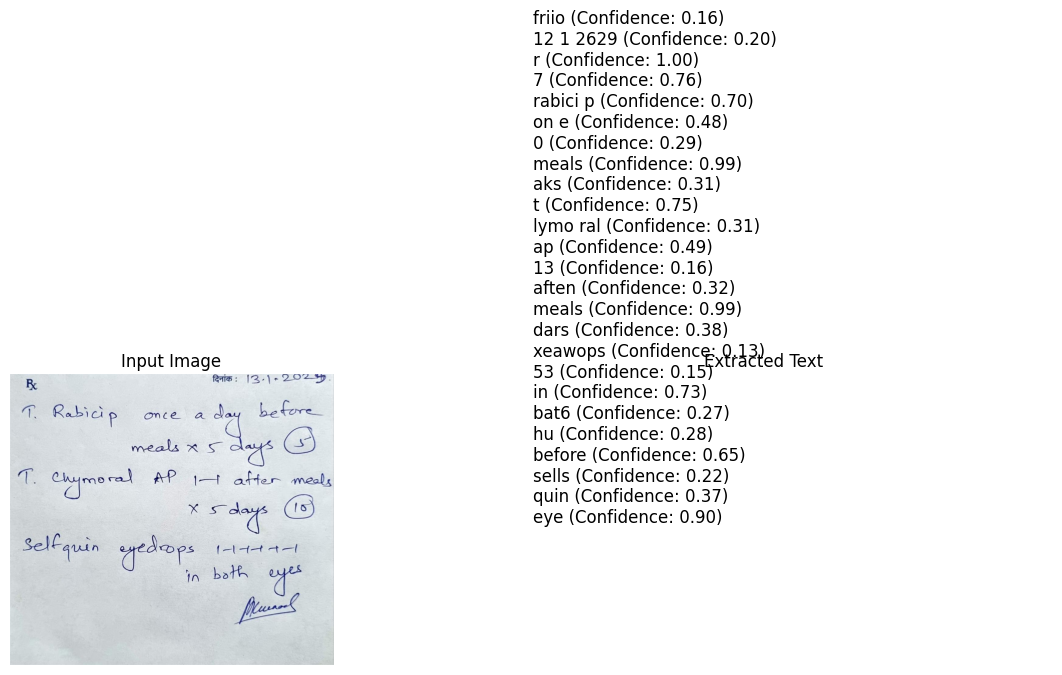

In [9]:

import easyocr
import numpy as np
import cv2
import matplotlib.pyplot as plt
from symspellpy import SymSpell, Verbosity

# Initialize SymSpell for spelling correction
sym_spell = SymSpell(max_dictionary_edit_distance=2)
sym_spell.load_dictionary("frequency_dictionary_en_82_765.txt", 0, 1)

# Preprocessing function
def preprocess_image(image):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    blurred = cv2.GaussianBlur(gray, (3, 3), 0)
    return blurred

# Correct spelling using SymSpell
def correct_spelling(text):
    suggestions = sym_spell.lookup_compound(text, max_edit_distance=2)
    return suggestions[0].term if suggestions else text

# Hybrid OCR pipeline (EasyOCR + Spelling Correction)
def hybrid_ocr(image_path, confidence_threshold=0.7):
    reader = easyocr.Reader(['en'])
    image = cv2.imread(image_path)
    image = preprocess_image(image)

    # Run EasyOCR
    results = reader.readtext(image, detail=1)
    extracted_text = []

    for (bbox, text, confidence) in results:
        corrected_text = correct_spelling(text)
        extracted_text.append(f"{corrected_text} (Confidence: {confidence:.2f})")

    # Generate final extracted text
    final_text = "\n".join(extracted_text)

    print("\nFinal Extracted Text:\n", final_text)
    return image, final_text.strip()

# Test the OCR pipeline
image_path = 'C:\Clg Project\FPresc.jpg'
image, final_text = hybrid_ocr(image_path, confidence_threshold=0.7)

# Display results
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(cv2.imread(image_path), cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.title('Input Image')

plt.subplot(1, 2, 2)
plt.text(0.1, 0.5, final_text, fontsize=12, wrap=True)
plt.axis('off')
plt.title('Extracted Text')

plt.tight_layout()
plt.show()


2025-02-07 18:55:02,997: E symspellpy.symspellpy] Dictionary file not found at frequency_dictionary_en_82_765.txt.


Detected: Advice;, Confidence: 0.7454
Detected: Syp CALPOL @so/5), Confidence: 0.6706
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
Low confidence detected. Using CRNN model prediction: o
Detected: Qeh * 3, Confidence: 0.7034
Detected: d, Confidence: 0.9582
Detected: SYp, Confidence: 0.4279
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
Low confidence detected. Using CRNN model prediction: d
Detected: Delcorv, Confidence: 0.4440
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
Low confidence detected. Using CRNN model prediction: u
Detected: 3 mL, Confidence: 0.8870
Detected: sd, Confidence: 0.9999
Detected: SYp, Confidence: 0.2568
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
Low confidence detected. Using CRNN model prediction: o
Detected: LEvoLIN, Confidence: 0.5628
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
Low confidence detected. Using CRNN model prediction: m
Detected: ML, Confidence: 0.6396
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
Low confidence detected. Using CRNN model prediction: m
Detected: sd, Confidence: 0.4546
1/

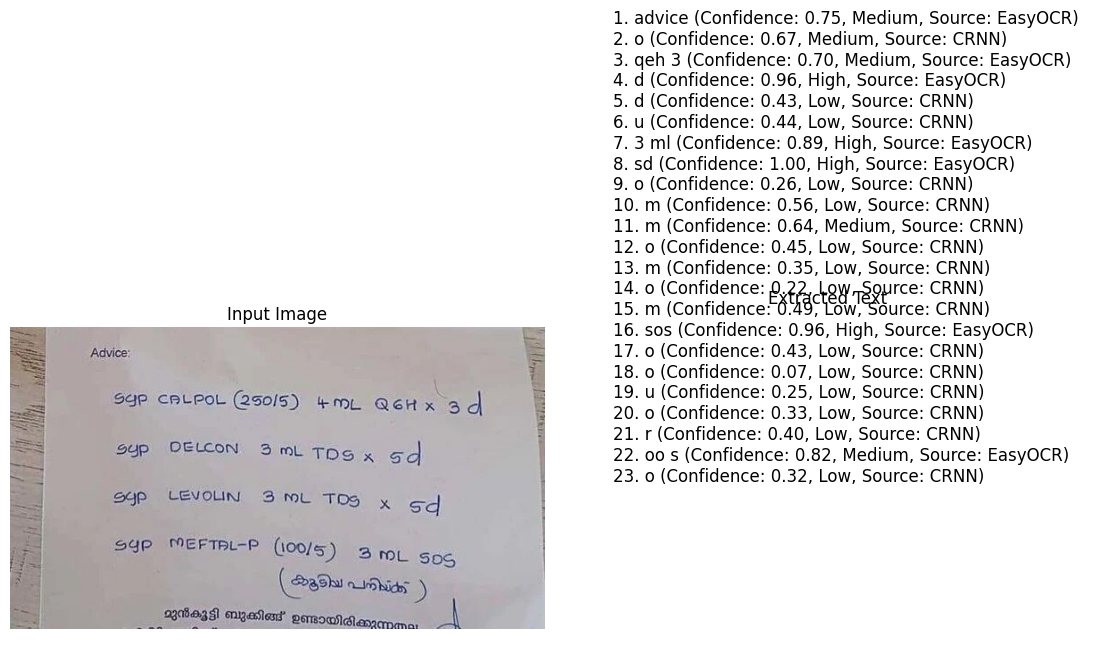

In [10]:
import easyocr
import numpy as np
import cv2
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model
from symspellpy import SymSpell, Verbosity

# Initialize SymSpell for spelling correction
sym_spell = SymSpell(max_dictionary_edit_distance=2)
sym_spell.load_dictionary("frequency_dictionary_en_82_765.txt", 0, 1)

# ✅ Load the trained CRNN model
crnn_model = load_model("C:/Data Set/A_Z_Handwritten_Model.h5")

# Class mapping (A-Z)
class_map = {i: chr(65 + i) for i in range(26)}

# ✅ Enhanced Preprocessing for CRNN Model
def enhanced_preprocess(image):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    blurred = cv2.GaussianBlur(gray, (3, 3), 0)

    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    contrast_enhanced = clahe.apply(blurred)

    thresholded = cv2.adaptiveThreshold(
        contrast_enhanced, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 11, 2
    )

    resized = cv2.resize(thresholded, (28, 28), interpolation=cv2.INTER_AREA)
    normalized = resized.astype('float32') / 255.0
    reshaped = np.expand_dims(normalized, axis=-1)
    return np.expand_dims(reshaped, axis=0)

# ✅ Use Your Trained Model for OCR
def extract_text_crnn(image):
    preprocessed_image = enhanced_preprocess(image)
    prediction = crnn_model.predict(preprocessed_image)
    predicted_class = np.argmax(prediction, axis=-1)
    text = ''.join([class_map[char] for char in predicted_class])
    return text

# ✅ Categorize Confidence
def categorize_confidence(confidence):
    if confidence >= 0.85:
        return 'High'
    elif confidence >= 0.60:
        return 'Medium'
    else:
        return 'Low'

# ✅ Correct Spelling Using SymSpell
def correct_spelling(text):
    suggestions = sym_spell.lookup_compound(text, max_edit_distance=2)
    return suggestions[0].term if suggestions else text

# ✅ Hybrid OCR Pipeline
def hybrid_ocr(image_path, confidence_threshold=0.7):
    reader = easyocr.Reader(['en'])
    image = cv2.imread(image_path)

    # Run EasyOCR
    results = reader.readtext(image, detail=1)
    prescription_text = []
    easyocr_count = 0
    crnn_count = 0

    for (bbox, text, confidence) in results:
        print(f"Detected: {text}, Confidence: {confidence:.4f}")

        if confidence < confidence_threshold:
            x_min, y_min = map(int, bbox[0])
            x_max, y_max = map(int, bbox[2])
            character_image = image[y_min:y_max, x_min:x_max]

            crnn_text = extract_text_crnn(character_image)
            crnn_text = correct_spelling(crnn_text)
            print(f"Low confidence detected. Using CRNN model prediction: {crnn_text}")

            prescription_text.append((crnn_text, confidence, 'CRNN', categorize_confidence(confidence)))
            crnn_count += 1
        else:
            text = correct_spelling(text)
            prescription_text.append((text, confidence, 'EasyOCR', categorize_confidence(confidence)))
            easyocr_count += 1

    # ✅ Generate final extracted text
    final_text = "\n".join([f"{i+1}. {text} (Confidence: {confidence:.2f}, {category}, Source: {source})"
                            for i, (text, confidence, source, category) in enumerate(prescription_text)])

    summary = f"\nSummary:\nTotal Results: {easyocr_count + crnn_count}\n - EasyOCR: {easyocr_count}\n - CRNN: {crnn_count}"

    print(f"\nFinal Extracted Text:\n{final_text}{summary}")
    return image, final_text.strip()

# ✅ Test the Hybrid OCR Pipeline
image_path = 'C:/Users/vaibh/Downloads/prescription5.jpg'
image, final_text = hybrid_ocr(image_path)

# ✅ Display Results
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(cv2.imread(image_path), cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.title('Input Image')

plt.subplot(1, 2, 2)
plt.text(0.1, 0.5, final_text, fontsize=12, wrap=True)
plt.axis('off')
plt.title('Extracted Text')

plt.tight_layout()
plt.show()


2025-02-07 19:15:53,714: E symspellpy.symspellpy] Dictionary file not found at frequency_dictionary_en_82_765.txt.
ERROR:symspellpy.symspellpy:Dictionary file not found at frequency_dictionary_en_82_765.txt.



### EasyOCR Detection Results ###

EasyOCR detected: Advice;, Confidence: 0.7454
Spelling corrected: advice
Grammar corrected: advice
EasyOCR detected: Syp CALPOL @so/5), Confidence: 0.6706
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
CRNN Output: O
Spelling corrected: o
Grammar corrected: o
EasyOCR detected: Qeh * 3, Confidence: 0.7034
Spelling corrected: qeh 3
Grammar corrected: Qeh 3
EasyOCR detected: d, Confidence: 0.9582
Spelling corrected: d
Grammar corrected: d
EasyOCR detected: SYp, Confidence: 0.4279
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
CRNN Output: D
Spelling corrected: d
Grammar corrected: d
EasyOCR detected: Delcorv, Confidence: 0.4440
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
CRNN Output: U
Spelling corrected: u
Grammar corrected: u
EasyOCR detected: 3 mL, Confidence: 0.8870
Spelling corrected: 3 ml
Grammar corrected: 3 ml
EasyOCR detected: sd, Confidence: 0.9999
Spelling corrected: sd
Grammar corrected: SD
EasyOCR detected: SYp, Confidence: 0.2568
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/

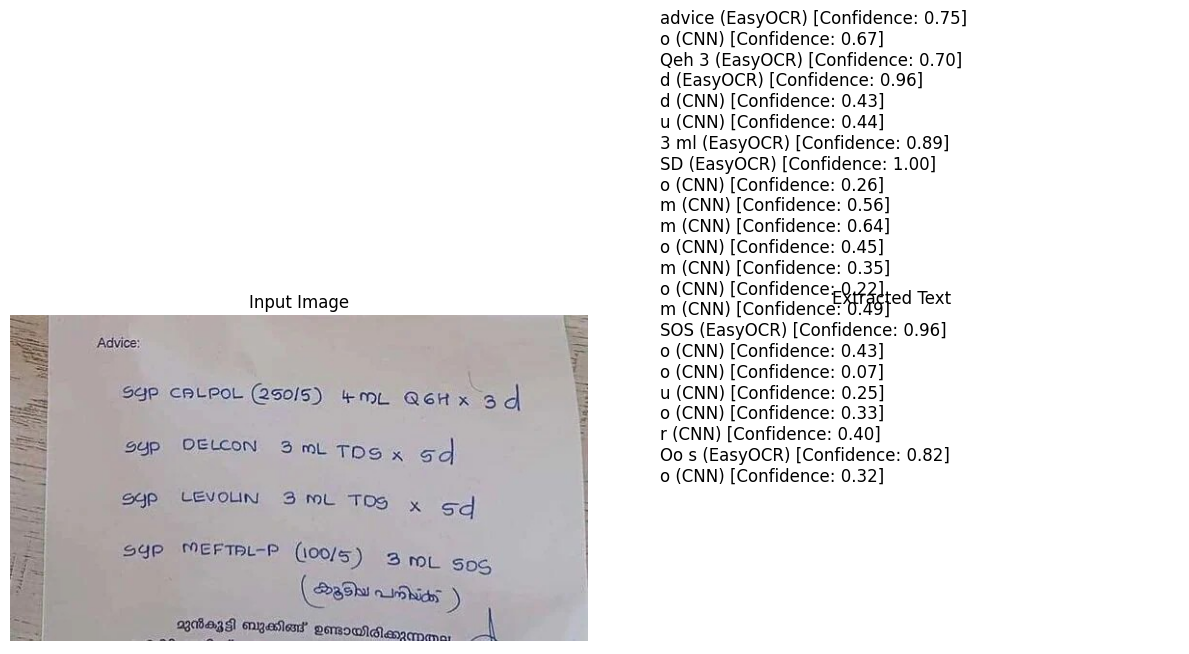

In [15]:
import easyocr
import numpy as np
import cv2
import matplotlib.pyplot as plt
import language_tool_python
from tensorflow.keras.models import load_model
from symspellpy import SymSpell, Verbosity

# Load trained CRNN model
crnn_model = load_model(r"C:\Data Set\A_Z_Handwritten_Model.h5")

# Initialize SymSpell for spelling correction
sym_spell = SymSpell(max_dictionary_edit_distance=2)
sym_spell.load_dictionary("frequency_dictionary_en_82_765.txt", 0, 1)

# Initialize LanguageTool for grammar correction
tool = language_tool_python.LanguageTool('en-US')

# Class mapping for A-Z
class_map = {i: chr(65 + i) for i in range(26)}

# Enhanced Preprocessing for CRNN
def enhanced_preprocess(image):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    blurred = cv2.GaussianBlur(gray, (3, 3), 0)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    contrast_enhanced = clahe.apply(blurred)
    thresholded = cv2.adaptiveThreshold(
        contrast_enhanced, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 11, 2
    )
    resized = cv2.resize(thresholded, (28, 28), interpolation=cv2.INTER_AREA)
    normalized = resized.astype('float32') / 255.0
    reshaped = np.expand_dims(normalized, axis=-1)
    return np.expand_dims(reshaped, axis=0)

# CRNN prediction
def extract_text_crnn(image):
    preprocessed_image = enhanced_preprocess(image)
    prediction = crnn_model.predict(preprocessed_image)
    predicted_class = np.argmax(prediction, axis=-1)
    text = ''.join([class_map[char] for char in predicted_class])
    print(f"CRNN Output: {text}")  # Debugging output
    return text

# Word Segmentation using MSER
def segment_words(image):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    mser = cv2.MSER_create()
    regions, _ = mser.detectRegions(gray)
    
    word_images = []
    for (x, y, w, h) in [cv2.boundingRect(p.reshape(-1, 1, 2)) for p in regions]:
        if w * h > 100:  # Ignore small regions
            word_images.append(image[y:y+h, x:x+w])
    
    return word_images

# Correct spelling using SymSpell
def correct_spelling(text):
    suggestions = sym_spell.lookup_compound(text, max_edit_distance=2)
    corrected_text = suggestions[0].term if suggestions else text
    print(f"Spelling corrected: {corrected_text}")  # Debugging output
    return corrected_text

# Correct grammar using LanguageTool
def correct_grammar(text):
    corrected_text = tool.correct(text)
    print(f"Grammar corrected: {corrected_text}")  # Debugging output
    return corrected_text

# Hybrid OCR pipeline
def hybrid_ocr(image_path, confidence_threshold=0.7):
    reader = easyocr.Reader(['en'])
    image = cv2.imread(image_path)
    
    # Run EasyOCR
    results = reader.readtext(image, detail=1)
    prescription_text = []
    easyocr_count = 0
    crnn_count = 0

    print("\n### EasyOCR Detection Results ###\n")
    for (bbox, text, confidence) in results:
        print(f"EasyOCR detected: {text}, Confidence: {confidence:.4f}")

        # Use CRNN for low-confidence text
        if confidence < confidence_threshold:
            x_min, y_min = map(int, bbox[0])
            x_max, y_max = map(int, bbox[2])
            character_image = image[y_min:y_max, x_min:x_max]
            
            crnn_text = extract_text_crnn(character_image)
            crnn_text = correct_spelling(crnn_text)
            crnn_text = correct_grammar(crnn_text)
            prescription_text.append(f"{crnn_text} (CNN) [Confidence: {confidence:.2f}]")
            crnn_count += 1
        else:
            text = correct_spelling(text)
            text = correct_grammar(text)
            prescription_text.append(f"{text} (EasyOCR) [Confidence: {confidence:.2f}]")
            easyocr_count += 1

    final_text = "\n".join(prescription_text)

    # Display final extracted text
    print("\n### Final Extracted Text ###\n")
    print(final_text)

    return image, final_text.strip()

# Test the hybrid OCR pipeline
image_path = r'C:/Users/vaibh/Downloads/prescription5.jpg'
image, final_text = hybrid_ocr(image_path, confidence_threshold=0.7)

# Display results
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(cv2.imread(image_path), cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.title('Input Image')

plt.subplot(1, 2, 2)
plt.text(0.1, 0.5, final_text, fontsize=12, wrap=True)
plt.axis('off')
plt.title('Extracted Text')

plt.tight_layout()
plt.show()


Compiled the loaded model, but the compiled metrics have yet to be built. `model.compile_metrics` will be empty until you train or evaluate the model.
2025-02-14 12:43:30,608: E symspellpy.symspellpy] Dictionary file not found at frequency_dictionary_en_82_765.txt.
Dictionary file not found at frequency_dictionary_en_82_765.txt.
Neither CUDA nor MPS are available - defaulting to CPU. Note: This module is much faster with a GPU.
C:\Users\vaibh\miniconda3\Lib\site-packages\easyocr\detection.py:78: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. 


### EasyOCR Detection Results ###

EasyOCR detected: Advice;, Confidence: 0.7454
Spelling corrected: advice
Grammar corrected: advice
EasyOCR detected: Syp CALPOL @so/5), Confidence: 0.6706
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 254ms/step
CRNN Output: O
Spelling corrected: o
Grammar corrected: o
EasyOCR detected: Qeh * 3, Confidence: 0.7034
Spelling corrected: qeh 3
Grammar corrected: Qeh 3
EasyOCR detected: d, Confidence: 0.9582
Spelling corrected: d
Grammar corrected: d
EasyOCR detected: SYp, Confidence: 0.4279
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
CRNN Output: D
Spelling corrected: d
Grammar corrected: d
EasyOCR detected: Delcorv, Confidence: 0.4440
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
CRNN Output: U
Spelling corrected: u
Grammar corrected: u
EasyOCR detected: 3 mL, Confidence: 0.8870
Spelling corrected: 3 ml
Grammar corrected: 3 ml
EasyOCR detected: sd, Confidence: 0.9999
Spelling corrected: sd
Grammar corrected: SD
EasyOCR detected: SYp, Confidence: 0.2568
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms

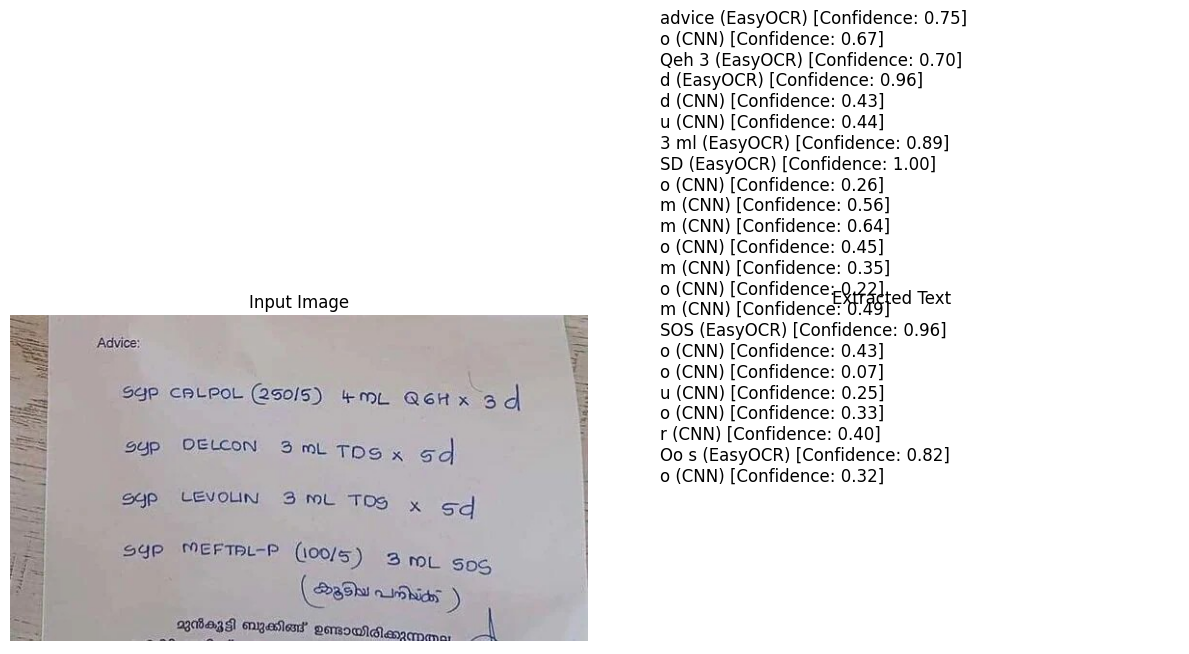

In [1]:
import easyocr
import numpy as np
import cv2
import matplotlib.pyplot as plt
import language_tool_python
from tensorflow.keras.models import load_model
from symspellpy import SymSpell, Verbosity

# Load trained CRNN model
crnn_model = load_model(r"C:\Data Set\A_Z_Handwritten_Model.h5")

# Initialize SymSpell for spelling correction
sym_spell = SymSpell(max_dictionary_edit_distance=2)
sym_spell.load_dictionary("frequency_dictionary_en_82_765.txt", 0, 1)

# Initialize LanguageTool for grammar correction
tool = language_tool_python.LanguageTool('en-US')

# Class mapping for A-Z
class_map = {i: chr(65 + i) for i in range(26)}

# Enhanced Preprocessing for CRNN
def enhanced_preprocess(image):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    blurred = cv2.GaussianBlur(gray, (3, 3), 0)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    contrast_enhanced = clahe.apply(blurred)
    thresholded = cv2.adaptiveThreshold(
        contrast_enhanced, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 11, 2
    )
    resized = cv2.resize(thresholded, (28, 28), interpolation=cv2.INTER_AREA)
    normalized = resized.astype('float32') / 255.0
    reshaped = np.expand_dims(normalized, axis=-1)
    return np.expand_dims(reshaped, axis=0)

# CRNN prediction
def extract_text_crnn(image):
    preprocessed_image = enhanced_preprocess(image)
    prediction = crnn_model.predict(preprocessed_image)
    predicted_class = np.argmax(prediction, axis=-1)
    text = ''.join([class_map[char] for char in predicted_class])
    print(f"CRNN Output: {text}")  # Debugging output
    return text

# Word Segmentation using MSER
def segment_words(image):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    mser = cv2.MSER_create()
    regions, _ = mser.detectRegions(gray)
    
    word_images = []
    for (x, y, w, h) in [cv2.boundingRect(p.reshape(-1, 1, 2)) for p in regions]:
        if w * h > 100:  # Ignore small regions
            word_images.append(image[y:y+h, x:x+w])
    
    return word_images

# Correct spelling using SymSpell
def correct_spelling(text):
    suggestions = sym_spell.lookup_compound(text, max_edit_distance=2)
    corrected_text = suggestions[0].term if suggestions else text
    print(f"Spelling corrected: {corrected_text}")  # Debugging output
    return corrected_text

# Correct grammar using LanguageTool
def correct_grammar(text):
    corrected_text = tool.correct(text)
    print(f"Grammar corrected: {corrected_text}")  # Debugging output
    return corrected_text

# Hybrid OCR pipeline
def hybrid_ocr(image_path, confidence_threshold=0.7):
    reader = easyocr.Reader(['en'])
    image = cv2.imread(image_path)
    
    # Run EasyOCR
    results = reader.readtext(image, detail=1)
    prescription_text = []
    easyocr_count = 0
    crnn_count = 0

    print("\n### EasyOCR Detection Results ###\n")
    for (bbox, text, confidence) in results:
        print(f"EasyOCR detected: {text}, Confidence: {confidence:.4f}")

        # Use CRNN for low-confidence text
        if confidence < confidence_threshold:
            x_min, y_min = map(int, bbox[0])
            x_max, y_max = map(int, bbox[2])
            character_image = image[y_min:y_max, x_min:x_max]
            
            crnn_text = extract_text_crnn(character_image)
            crnn_text = correct_spelling(crnn_text)
            crnn_text = correct_grammar(crnn_text)
            prescription_text.append(f"{crnn_text} (CNN) [Confidence: {confidence:.2f}]")
            crnn_count += 1
        else:
            text = correct_spelling(text)
            text = correct_grammar(text)
            prescription_text.append(f"{text} (EasyOCR) [Confidence: {confidence:.2f}]")
            easyocr_count += 1

    final_text = "\n".join(prescription_text)

    # Display final extracted text
    print("\n### Final Extracted Text ###\n")
    print(final_text)

    return image, final_text.strip()

# Test the hybrid OCR pipeline
image_path = r'C:/Users/vaibh/Downloads/prescription5.jpg'
image, final_text = hybrid_ocr(image_path, confidence_threshold=0.7)

# Display results
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(cv2.imread(image_path), cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.title('Input Image')

plt.subplot(1, 2, 2)
plt.text(0.1, 0.5, final_text, fontsize=12, wrap=True)
plt.axis('off')
plt.title('Extracted Text')

plt.tight_layout()
plt.show()jbhuvjn cvvvaibbagvvgtdhiubrffhukrbplt.show is what we want in this type

Compiled the loaded model, but the compiled metrics have yet to be built. `model.compile_metrics` will be empty until you train or evaluate the model.
2025-02-14 12:49:32,234: E symspellpy.symspellpy] Dictionary file not found at frequency_dictionary_en_82_765.txt.
Dictionary file not found at frequency_dictionary_en_82_765.txt.


FileNotFoundError: [Errno 2] No such file or directory: 'medicine_names.txt'

Compiled the loaded model, but the compiled metrics have yet to be built. `model.compile_metrics` will be empty until you train or evaluate the model.
Neither CUDA nor MPS are available - defaulting to CPU. Note: This module is much faster with a GPU.
C:\Users\vaibh\miniconda3\Lib\site-packages\easyocr\detection.py:78: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend y


### EasyOCR Detection Results ###

EasyOCR detected: Advice;, Confidence: 0.7454
Spelling corrected: advice
Grammar corrected: advice
EasyOCR detected: Syp CALPOL @so/5), Confidence: 0.6706
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
CRNN Output: O
Spelling corrected: of
Grammar corrected: of
EasyOCR detected: Qeh * 3, Confidence: 0.7034
Spelling corrected: meh a
Grammar corrected: meh, a
EasyOCR detected: d, Confidence: 0.9582
Spelling corrected: a
Grammar corrected: a
EasyOCR detected: SYp, Confidence: 0.4279
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
CRNN Output: D
Spelling corrected: a
Grammar corrected: a
EasyOCR detected: Delcorv, Confidence: 0.4440
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
CRNN Output: U
Spelling corrected: a
Grammar corrected: a
EasyOCR detected: 3 mL, Confidence: 0.8870
Spelling corrected: a my
Grammar corrected: a
EasyOCR detected: sd, Confidence: 0.9999
Spelling corrected: so
Grammar corrected: so
EasyOCR detected: SYp, Confidence: 0.2568
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/

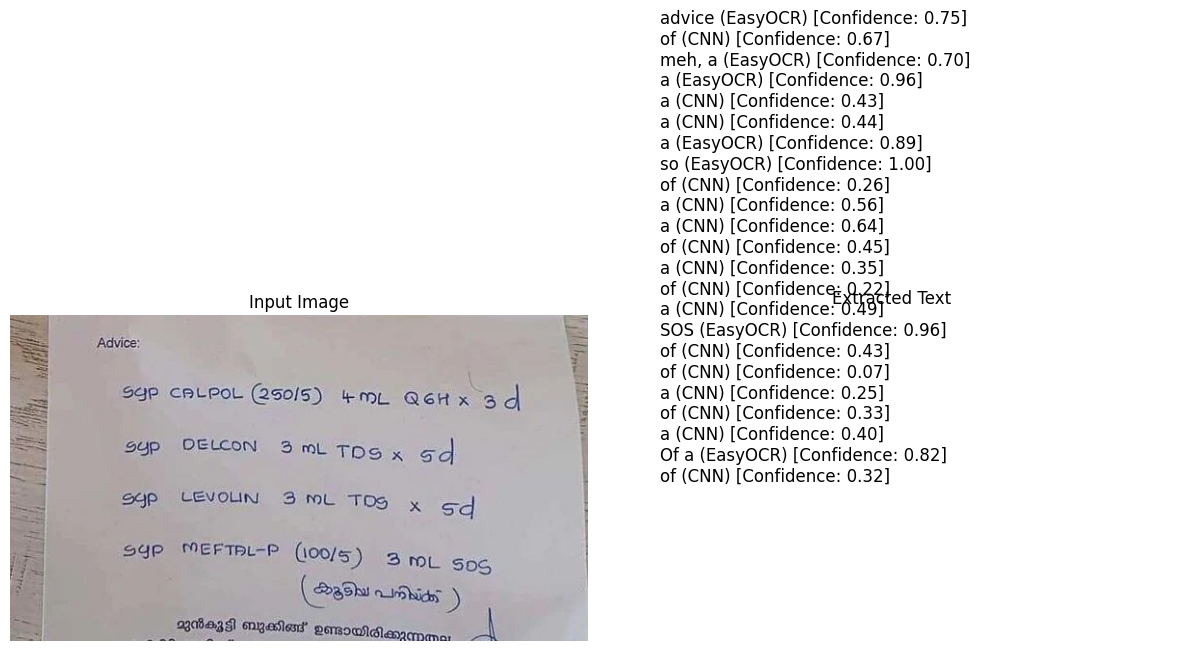

In [2]:
import easyocr
import numpy as np
import cv2
import matplotlib.pyplot as plt
import language_tool_python
from tensorflow.keras.models import load_model
from symspellpy import SymSpell, Verbosity
import os

# Load trained CRNN model
crnn_model = load_model(r"C:\Data Set\A_Z_Handwritten_Model.h5")

# Initialize SymSpell for spelling correction
dictionary_path = r"C:\Users\vaibh\Downloads\frequency_dictionary_en_82_765.txt"
if not os.path.exists(dictionary_path):
    raise FileNotFoundError(f"Dictionary not found: {dictionary_path}")

sym_spell = SymSpell(max_dictionary_edit_distance=2)
sym_spell.load_dictionary(dictionary_path, 0, 1)

# Initialize LanguageTool for grammar correction
tool = language_tool_python.LanguageTool('en-US')

# Class mapping for A-Z
class_map = {i: chr(65 + i) for i in range(26)}

# Enhanced Preprocessing for CRNN
def enhanced_preprocess(image):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    blurred = cv2.GaussianBlur(gray, (3, 3), 0)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    contrast_enhanced = clahe.apply(blurred)
    thresholded = cv2.adaptiveThreshold(
        contrast_enhanced, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 11, 2
    )
    resized = cv2.resize(thresholded, (28, 28), interpolation=cv2.INTER_AREA)
    normalized = resized.astype('float32') / 255.0
    reshaped = np.expand_dims(normalized, axis=-1)
    return np.expand_dims(reshaped, axis=0)

# CRNN prediction
def extract_text_crnn(image):
    preprocessed_image = enhanced_preprocess(image)
    prediction = crnn_model.predict(preprocessed_image)
    predicted_classes = np.argmax(prediction, axis=-1)
    text = ''.join([class_map.get(char, '') for char in predicted_classes])
    print(f"CRNN Output: {text}")  # Debugging output
    
    # Filter out noisy output
    if not all(char.isalpha() for char in text):
        print("Skipping noisy CRNN output")
        return ""
    return text

# Correct spelling using SymSpell
def correct_spelling(text):
    suggestions = sym_spell.lookup_compound(text, max_edit_distance=2)
    corrected_text = suggestions[0].term if suggestions else text
    print(f"Spelling corrected: {corrected_text}")  # Debugging output
    return corrected_text

# Correct grammar using LanguageTool
def correct_grammar(text):
    corrected_text = tool.correct(text)
    print(f"Grammar corrected: {corrected_text}")  # Debugging output
    return corrected_text

# Hybrid OCR pipeline
def hybrid_ocr(image_path, confidence_threshold=0.7):
    reader = easyocr.Reader(['en'], gpu=True)
    image = cv2.imread(image_path)
    
    # Run EasyOCR
    results = reader.readtext(image, detail=1)
    if not results:
        print("No text detected by EasyOCR.")
        return image, ""
    
    prescription_text = []
    easyocr_count = 0
    crnn_count = 0

    print("\n### EasyOCR Detection Results ###\n")
    for (bbox, text, confidence) in results:
        print(f"EasyOCR detected: {text}, Confidence: {confidence:.4f}")

        # Use CRNN for low-confidence text
        if confidence < confidence_threshold:
            x_min, y_min = map(int, bbox[0])
            x_max, y_max = map(int, bbox[2])
            
            if x_max > x_min and y_max > y_min:  # Avoid empty regions
                character_image = image[y_min:y_max, x_min:x_max]
                crnn_text = extract_text_crnn(character_image)
                if crnn_text:
                    crnn_text = correct_spelling(crnn_text)
                    crnn_text = correct_grammar(crnn_text)
                    prescription_text.append(f"{crnn_text} (CNN) [Confidence: {confidence:.2f}]")
                    crnn_count += 1
            else:
                print("Skipping empty character region")
        else:
            text = correct_spelling(text)
            text = correct_grammar(text)
            prescription_text.append(f"{text} (EasyOCR) [Confidence: {confidence:.2f}]")
            easyocr_count += 1

    final_text = "\n".join(prescription_text)

    # Display final extracted text
    print("\n### Final Extracted Text ###\n")
    print(final_text)

    return image, final_text.strip()

# Test the hybrid OCR pipeline
image_path = r'C:/Users/vaibh/Downloads/prescription5.jpg'
image, final_text = hybrid_ocr(image_path, confidence_threshold=0.7)

# Display results
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(cv2.imread(image_path), cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.title('Input Image')

plt.subplot(1, 2, 2)
plt.text(0.1, 0.5, final_text, fontsize=12, wrap=True)
plt.axis('off')
plt.title('Extracted Text')

plt.tight_layout()
plt.show()


In [1]:
pip install pytesseract


Note: you may need to restart the kernel to use updated packages.


In [2]:
pip install pillow

Note: you may need to restart the kernel to use updated packages.


Recognized Text:
 Extract text
from image,



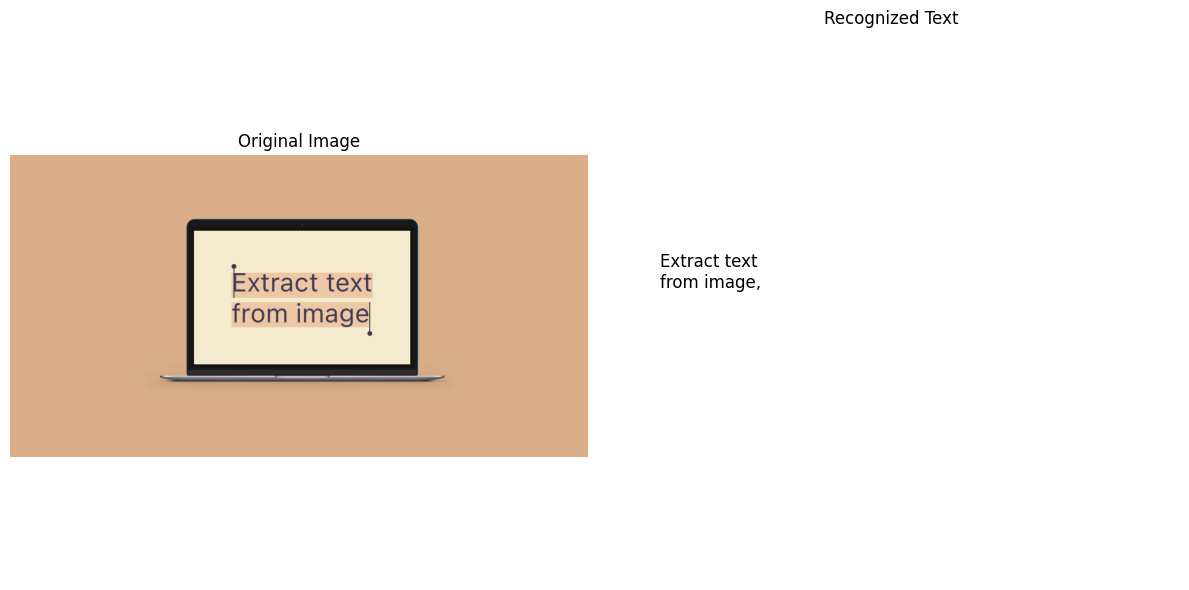

In [28]:
import pytesseract
from PIL import Image
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

# Set the path to the Tesseract executable (if needed)
# Replace with your actual path if Tesseract is not in your system's PATH
# Example for Windows:
pytesseract.pytesseract.tesseract_cmd = r'C:\Program Files\Tesseract-OCR\tesseract.exe'

def preprocess_handwriting(image_path):
    """Preprocesses the image for better handwriting recognition."""
    try:
        img = cv2.imread(image_path)
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        blurred = cv2.GaussianBlur(gray, (5, 5), 0)
        thresh = cv2.adaptiveThreshold(blurred, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY_INV, 11, 2)
        return Image.fromarray(thresh)
    except Exception as e:
        print(f"Error during preprocessing: {e}")
        return None

def recognize_handwriting(image_path):
    """Recognizes handwriting from the given image."""
    preprocessed_image = preprocess_handwriting(image_path)
    if preprocessed_image is None:
        return ""  # Return empty string if preprocessing failed

    try:
        config = r'--oem 3 --psm 6'  # OEM 3 for LSTM, PSM 6 for single line
        text = pytesseract.image_to_string(preprocessed_image, config=config)
        return text
    except pytesseract.TesseractError as e:
        print(f"Tesseract error: {e}")
        return "" #Return empty string if tesseract fails.
    except Exception as e:
        print(f"General error during recognition: {e}")
        return "" #Return empty string on general errors.

def display_image_and_text(image_path, recognized_text):
    """Displays the image and recognized text."""
    try:
        image = cv2.imread(image_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        plt.figure(figsize=(12, 6))
        plt.subplot(1, 2, 1)
        plt.imshow(image)
        plt.title("Original Image")
        plt.axis('off')

        plt.subplot(1, 2, 2)
        plt.text(0.1, 0.5, recognized_text, fontsize=12, wrap=True)
        plt.title("Recognized Text")
        plt.axis('off')

        plt.tight_layout()
        plt.show()
    except Exception as e:
        print(f"Error during display: {e}")

# Example usage
image_path = "C:/Users/vaibh/Downloads/img.png"  # Replace with your image path

if os.path.exists(image_path):
    recognized_text = recognize_handwriting(image_path)
    print("Recognized Text:\n", recognized_text)
    display_image_and_text(image_path, recognized_text)
else:
    print(f"Error: Image file not found at {image_path}")

In [26]:
import pytesseract
from PIL import Image
import cv2
import numpy as np
from tensorflow.keras.models import load_model  # Assuming you have a CRNN model
# Add symspell if spell correction is needed.

# Load your CRNN model and class mapping
crnn_model = load_model("C:/Data Set/Trained model/tanmay model_Gem.keras")  # Replace with your model path
class_map = {i: chr(65 + i) for i in range(26)}  # Example for A-Z

# CRNN Preprocessing function(same as before)
def crnn_preprocess(image):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)
    thresh = cv2.adaptiveThreshold(blurred, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY_INV, 11, 2)
    resized = cv2.resize(thresh, (28, 28), interpolation=cv2.INTER_AREA)
    normalized = resized.astype('float32') / 255.0
    reshaped = np.expand_dims(normalized, axis=-1)
    return np.expand_dims(reshaped, axis=0)

# CRNN Text extraction function
def crnn_extract_text(image_crop):
    preprocessed_image = crnn_preprocess(image_crop)
    prediction = crnn_model.predict(preprocessed_image)
    predicted_class = np.argmax(prediction, axis=-1)
    text = ''.join([class_map[char] for char in predicted_class])
    return text

def hybrid_ocr(image_path, confidence_threshold=0.6):
    img = cv2.imread(image_path)
    pil_img = Image.fromarray(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)) #convert to pil image.

    # PyTesseract OCR
    pytess_data = pytesseract.image_to_data(pil_img, output_type=pytesseract.Output.DICT)
    final_text = []

    for i in range(len(pytess_data['text'])):
        if int(pytess_data['conf'][i]) > confidence_threshold:
            final_text.append(pytess_data['text'][i])
        else:
            if pytess_data['text'][i].strip(): #check if there is text in the box.
                (x, y, w, h) = (pytess_data['left'][i], pytess_data['top'][i], pytess_data['width'][i], pytess_data['height'][i])
                crop = img[y:y + h, x:x + w]
                crnn_text = crnn_extract_text(crop)
                final_text.append(crnn_text)

    return " ".join(final_text)

image_path = "C:/Users/vaibh/Downloads/sj3.jpg"
result = hybrid_ocr(image_path)
print(result)

2025-04-09 15:44:34,243: E symspellpy.symspellpy] Dictionary file not found at frequency_dictionary_en_82_765.txt.
ERROR:symspellpy.symspellpy:Dictionary file not found at frequency_dictionary_en_82_765.txt.



Final Extracted Text:

Summary:
Total Results: 0
 - Tesseract: 0
 - CRNN: 0


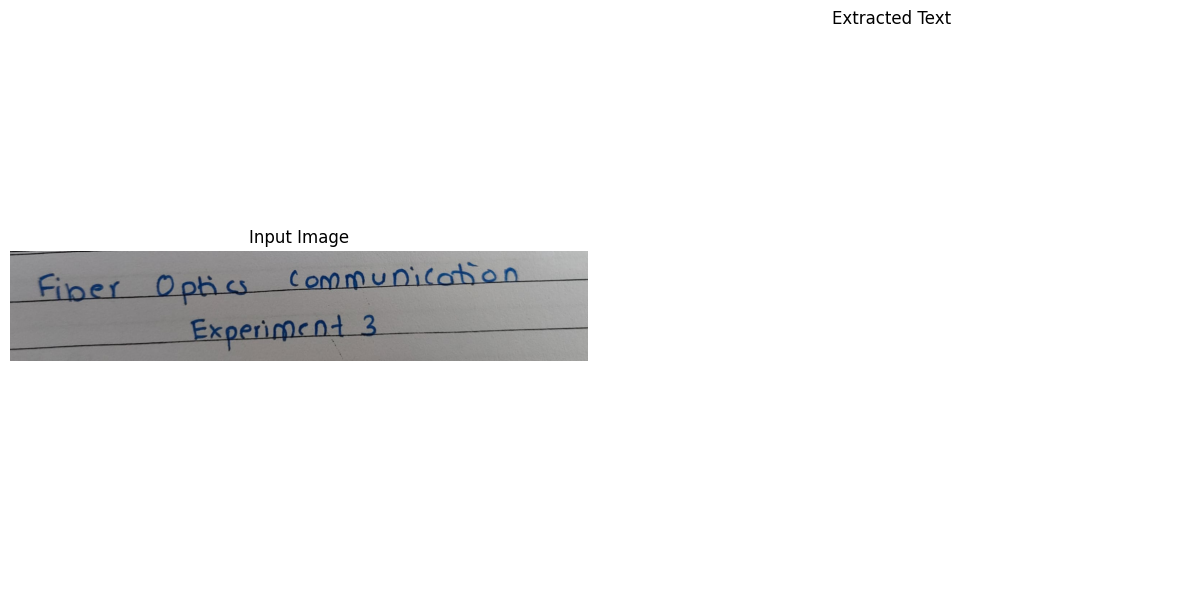

In [3]:
import pytesseract
from pytesseract import Output
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model
from symspellpy import SymSpell, Verbosity

# --- Load SymSpell Dictionary ---
sym_spell = SymSpell(max_dictionary_edit_distance=2)
sym_spell.load_dictionary("frequency_dictionary_en_82_765.txt", 0, 1)

# --- Load CRNN Model ---
crnn_model = load_model("C:/Data Set/Trained model/A_Z_Handwritten_Model.h5")

# --- Class Map (A-Z) ---
class_map = {i: chr(65 + i) for i in range(26)}

# --- Image Preprocessing for CRNN ---
def enhanced_preprocess(image):
    image = cv2.resize(image, (128, 32))  # Resize to match model input
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    blurred = cv2.GaussianBlur(gray, (3, 3), 0)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    enhanced = clahe.apply(blurred)
    normalized = enhanced.astype('float32') / 255.0
    reshaped = np.expand_dims(normalized, axis=-1)
    return np.expand_dims(reshaped, axis=0)

# --- Image Preprocessing for Tesseract ---
def preprocess_for_tesseract(image):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    blurred = cv2.medianBlur(gray, 3)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    contrast = clahe.apply(blurred)
    thresh = cv2.adaptiveThreshold(
        contrast, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY, 31, 2
    )
    return thresh

# --- CRNN Inference ---
def extract_text_crnn(image):
    preprocessed_image = enhanced_preprocess(image)
    prediction = crnn_model.predict(preprocessed_image)
    predicted_class = np.argmax(prediction, axis=-1).flatten()
    try:
        text = ''.join([class_map[int(char)] for char in predicted_class if int(char) in class_map])
    except KeyError:
        text = ""
    return text

# --- Confidence Category ---
def categorize_confidence(confidence):
    if confidence >= 85:
        return 'High'
    elif confidence >= 60:
        return 'Medium'
    else:
        return 'Low'

# --- Spelling Correction ---
def correct_spelling(text):
    suggestions = sym_spell.lookup_compound(text, max_edit_distance=2)
    return suggestions[0].term if suggestions else text

# --- Hybrid OCR Using pytesseract + CRNN ---
def hybrid_ocr_tesseract(image_path, confidence_threshold=70):
    image = cv2.imread(image_path)
    preprocessed_image = preprocess_for_tesseract(image)

    results = pytesseract.image_to_data(preprocessed_image, output_type=Output.DICT)
    prescription_text = []
    tesseract_count = 0
    crnn_count = 0

    for i in range(len(results['text'])):
        text = results['text'][i].strip()
        conf = int(results['conf'][i])

        if not text: #using not text instead of text == ''
            continue

        x, y, w, h = results['left'][i], results['top'][i], results['width'][i], results['height'][i]
        word_img = image[y:y + h, x:x + w]

        if conf < confidence_threshold:
            if word_img.size == 0:
                continue
            crnn_text = extract_text_crnn(word_img)
            crnn_text = correct_spelling(crnn_text)
            print(f"Low confidence '{text}' ({conf}). Replacing with CRNN: {crnn_text}")
            prescription_text.append((crnn_text, conf, 'CRNN', categorize_confidence(conf)))
            crnn_count += 1
        else:
            corrected_text = correct_spelling(text)
            prescription_text.append((corrected_text, conf, 'Tesseract', categorize_confidence(conf)))
            tesseract_count += 1

    final_text = "\n".join(
        [f"{i+1}. {text} (Confidence: {confidence}%, {category}, Source: {source})"
         for i, (text, confidence, source, category) in enumerate(prescription_text)]
    )

    summary = f"\nSummary:\nTotal Results: {tesseract_count + crnn_count}\n - Tesseract: {tesseract_count}\n - CRNN: {crnn_count}"
    print(f"\nFinal Extracted Text:\n{final_text}{summary}")
    return image, final_text.strip()

# --- Visualization ---
image_path = 'C:/Users/vaibh/Downloads/tk2.jpg'
image, final_text = hybrid_ocr_tesseract(image_path)

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.title('Input Image')

plt.subplot(1, 2, 2)
plt.text(0.1, 0.5, final_text, fontsize=12, wrap=True)
plt.axis('off')
plt.title('Extracted Text')

plt.tight_layout()
plt.show()